# Assignment: U.S. Monthly Retail Sales (Jan 1992 – Jun 2021)

**Name:** Shaghayegh Malekshahi  
**Course:** Predictive analytics      
**Week:** 8  
**Date:** October 27, 2025

## Introduction

This project analyzes U.S. monthly retail sales data from January 1992 to June 2021.  
The objective is to build a time series model capable of forecasting the retail sales for the final 12 months (July 2020 – June 2021).  
The model’s performance will be evaluated using the Root Mean Squared Error (RMSE).


In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from textwrap import dedent
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
# Load and reshape the dataset

csv_path = Path("us_retail_sales.csv")
if not csv_path.exists():
    raise FileNotFoundError("Couldn't find 'us_retail_sales.csv' in the current folder.")

raw = pd.read_csv(csv_path)

In [3]:
# Detect whether file is wide  or already long
cols = [c.upper() for c in raw.columns]
wide_months = {"JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP","OCT","NOV","DEC"}
is_wide = ("YEAR" in cols) and (wide_months.issubset(set(cols)))

In [4]:
if is_wide:
    # Reshape from wide to long
    month_order = ["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP","OCT","NOV","DEC"]
    long = raw.melt(id_vars=["YEAR"], value_vars=month_order,
                    var_name="MONTH", value_name="RetailSales")
    month_map = {m:i+1 for i,m in enumerate(month_order)}
    long["MONTH_NUM"] = long["MONTH"].str.upper().map(month_map)
    long["DATE"] = pd.to_datetime(dict(year=long["YEAR"], month=long["MONTH_NUM"], day=1))
    ts = (long[["DATE","RetailSales"]]
          .sort_values("DATE")
          .set_index("DATE")
          .asfreq("MS"))
else:
    # Try to infer likely date & value columns
    date_candidates = [c for c in raw.columns if "date" in c.lower() or "month" in c.lower()]
    val_candidates  = [c for c in raw.columns if any(k in c.lower() for k in ["sale","value","amount","total"])]
    if not date_candidates or not val_candidates:
        raise ValueError("Could not infer date/value columns. Please provide columns for date and sales.")
    date_col = date_candidates[0]
    value_col = val_candidates[0]
    df = raw.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    ts = (df[[date_col, value_col]]
          .dropna()
          .sort_values(date_col)
          .set_index(date_col)
          .asfreq("MS"))
    ts.rename(columns={value_col: "RetailSales"}, inplace=True)

In [5]:
# Clean numeric and interpolate any rare gaps after asfreq
ts["RetailSales"] = pd.to_numeric(ts["RetailSales"], errors="coerce")
ts = ts.dropna(subset=["RetailSales"])
if ts["RetailSales"].isna().any():
    ts["RetailSales"] = ts["RetailSales"].interpolate("time")

start, end, n = ts.index.min(), ts.index.max(), ts.shape[0]
print(f"Time span: {start.date()} to {end.date()} | {n} monthly rows")

Time span: 1992-01-01 to 2021-06-01 | 354 monthly rows


## Data Visualization

The plot below displays the historical monthly retail sales.  
There is a clear upward trend over the years, strong yearly seasonality with peaks around November–December,  
and a sharp decline around early 2020 due to the COVID-19 pandemic, followed by a rapid recovery.


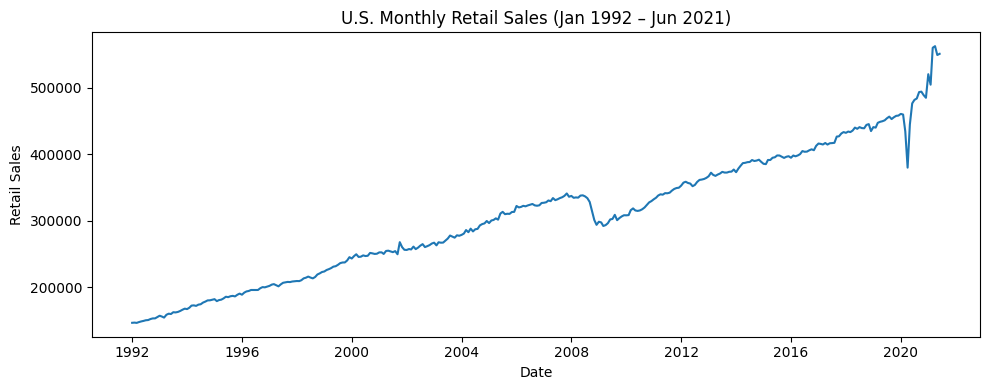

In [6]:
# Plot the full series with proper labeling

plt.figure(figsize=(10,4))
plt.plot(ts.index, ts["RetailSales"])
plt.title("U.S. Monthly Retail Sales (Jan 1992 – Jun 2021)")
plt.xlabel("Date")
plt.ylabel("Retail Sales")
plt.tight_layout()
plt.show()

In [7]:
# Quick observations
obs = {
    "start": str(start.date()),
    "end": str(end.date()),
    "count_months": int(n),
    "min": float(ts["RetailSales"].min()),
    "max": float(ts["RetailSales"].max()),
    "mean": float(ts["RetailSales"].mean())
}
print("\nBasic observations:")
for k,v in obs.items():
    print(f"  {k}: {v:.0f}" if isinstance(v,(int,float)) else f"  {k}: {v}")

print("\nVisual notes:")
print("- Long-term upward trend.")
print("- Clear annual seasonality (peaks near Nov–Dec, dips near Jan–Feb).")
print("- Large shock in 2020 with a sharp rebound (COVID-era).")


Basic observations:
  start: 1992-01-01
  end: 2021-06-01
  count_months: 354
  min: 146805
  max: 562269
  mean: 307007

Visual notes:
- Long-term upward trend.
- Clear annual seasonality (peaks near Nov–Dec, dips near Jan–Feb).
- Large shock in 2020 with a sharp rebound (COVID-era).


## Train–Test Split

To evaluate forecasting accuracy, the data was split into:

- **Training period:** January 1992 – June 2020  
- **Test period:** July 2020 – June 2021 (12 months)

The training data was used to fit the time series model, while the test data was used for evaluation.


In [8]:
# Train/Test split
# test = Jul 2020 – Jun 2021 (12 months)
test_h = 12
series = ts["RetailSales"].copy()
train = series.iloc[:-test_h]
test  = series.iloc[-test_h:]

print(f"\nTrain range: {train.index.min().date()} to {train.index.max().date()}")
print(f"Test  range: {test.index.min().date()} to {test.index.max().date()} (12 months)")


Train range: 1992-01-01 to 2020-06-01
Test  range: 2020-07-01 to 2021-06-01 (12 months)


## Model: Holt–Winters Exponential Smoothing

The Holt–Winters method was selected because it effectively captures both **trend** and **seasonality** in monthly retail data.  
The model uses additive trend and additive seasonality applied to the log-transformed data to stabilize variance.


In [10]:
# Build predictive model on training (Holt–Winters, log scale + additive seasonality)
y_train = np.log(train)          # stabilize variance
hw_fit = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
).fit(optimized=True)

# Forecast on log scale, then invert back
fcst_log = hw_fit.forecast(test_h)
forecast_hw = np.exp(fcst_log)

# Baseline: seasonal naive (y_t = y_(t-12)) on original scale (unchanged)
seasonal_naive = series.shift(12).iloc[-test_h:]

In [11]:
# Evaluate on the test set (RMSE)
rmse_hw = mean_squared_error(test, forecast_hw, squared=False)
rmse_sn = mean_squared_error(test, seasonal_naive, squared=False)

print(f"\nRMSE (Holt–Winters): {rmse_hw:,.2f}")
print(f"RMSE (Seasonal Naive): {rmse_sn:,.2f}")


RMSE (Holt–Winters): 42,797.33
RMSE (Seasonal Naive): 80,273.26


### Plots for results

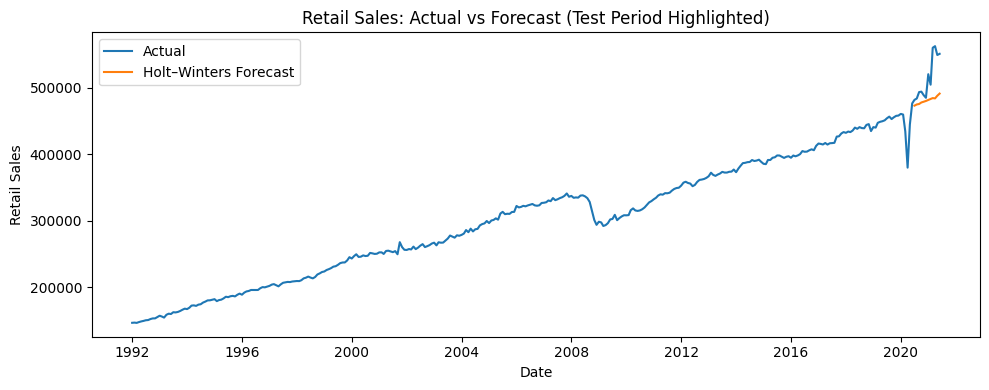

In [12]:
# Full series with model forecast line for the test period
plt.figure(figsize=(10,4))
plt.plot(series.index, series.values, label="Actual")
plt.plot(forecast_hw.index, forecast_hw.values, label="Holt–Winters Forecast")
plt.title("Retail Sales: Actual vs Forecast (Test Period Highlighted)")
plt.xlabel("Date")
plt.ylabel("Retail Sales")
plt.legend()
plt.tight_layout()
plt.show()

## Forecast Results

The following chart compares actual retail sales (blue) with the Holt–Winters forecast (orange)  
and the seasonal naive baseline (green) during the test period.


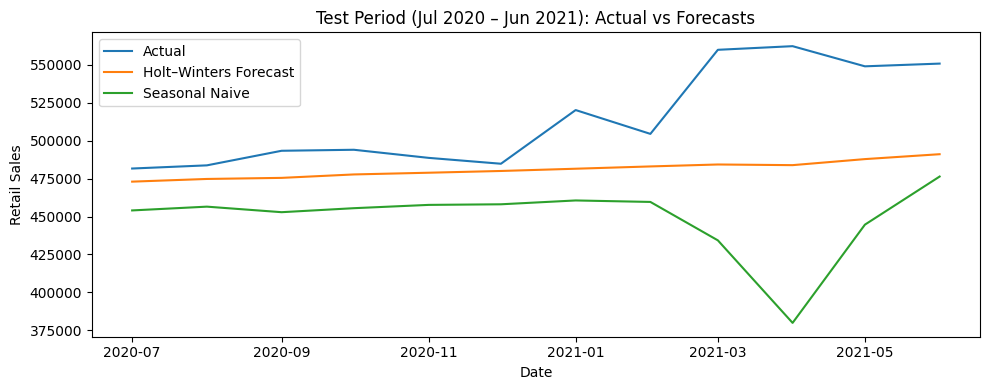

In [13]:
# Zoom on test window: Actual vs HW vs seasonal naive
plt.figure(figsize=(10,4))
plt.plot(test.index, test.values, label="Actual")
plt.plot(forecast_hw.index, forecast_hw.values, label="Holt–Winters Forecast")
plt.plot(seasonal_naive.index, seasonal_naive.values, label="Seasonal Naive")
plt.title("Test Period (Jul 2020 – Jun 2021): Actual vs Forecasts")
plt.xlabel("Date")
plt.ylabel("Retail Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Save submission artifacts
out_preds = pd.DataFrame({
    "Date": test.index,
    "Actual": test.values,
    "HW_Forecast": forecast_hw.values,
    "SeasonalNaive": seasonal_naive.values
})
out_preds.to_csv("us_retail_sales_predictions.csv", index=False)

In [15]:
# Save figures
plt.figure(figsize=(10,4))
plt.plot(ts.index, ts["RetailSales"])
plt.title("U.S. Monthly Retail Sales (Jan 1992 – Jun 2021)")
plt.xlabel("Date")
plt.ylabel("Retail Sales")
plt.tight_layout()
plt.savefig("retail_sales_full_series.png", dpi=200)
plt.close()

plt.figure(figsize=(10,4))
plt.plot(test.index, test.values, label="Actual")
plt.plot(forecast_hw.index, forecast_hw.values, label="Holt–Winters Forecast")
plt.plot(seasonal_naive.index, seasonal_naive.values, label="Seasonal Naive")
plt.title("Test Period (Jul 2020 – Jun 2021): Actual vs Forecasts")
plt.xlabel("Date")
plt.ylabel("Retail Sales")
plt.legend()
plt.tight_layout()
plt.savefig("retail_sales_test_forecast.png", dpi=200)
plt.close()

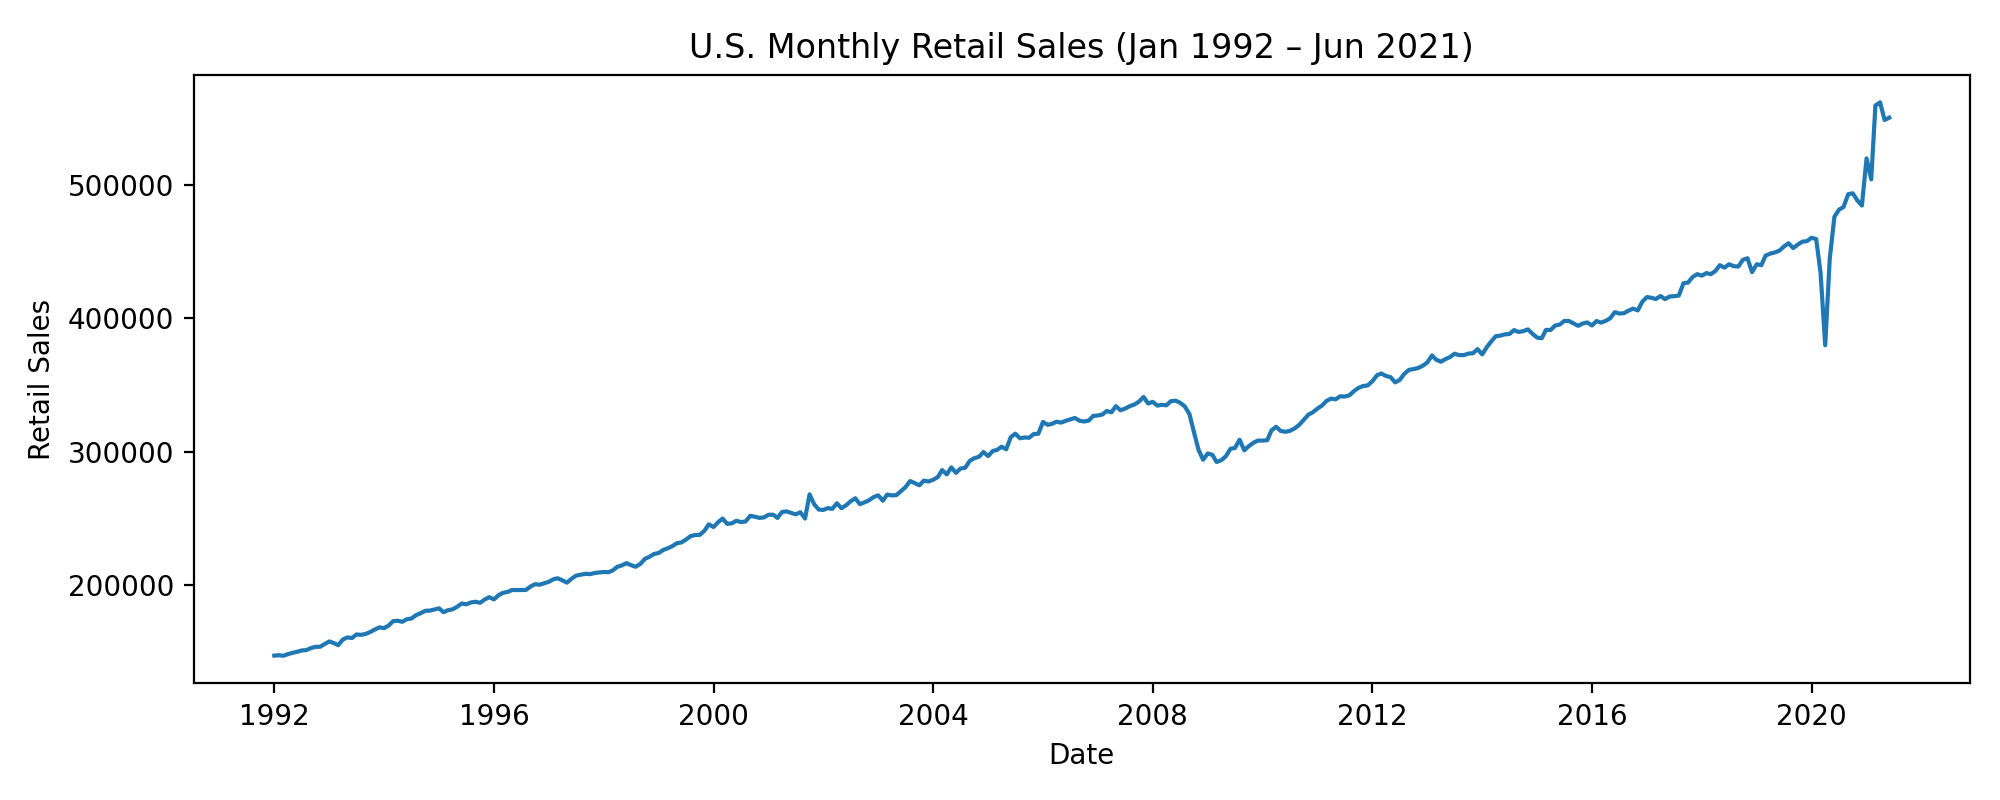

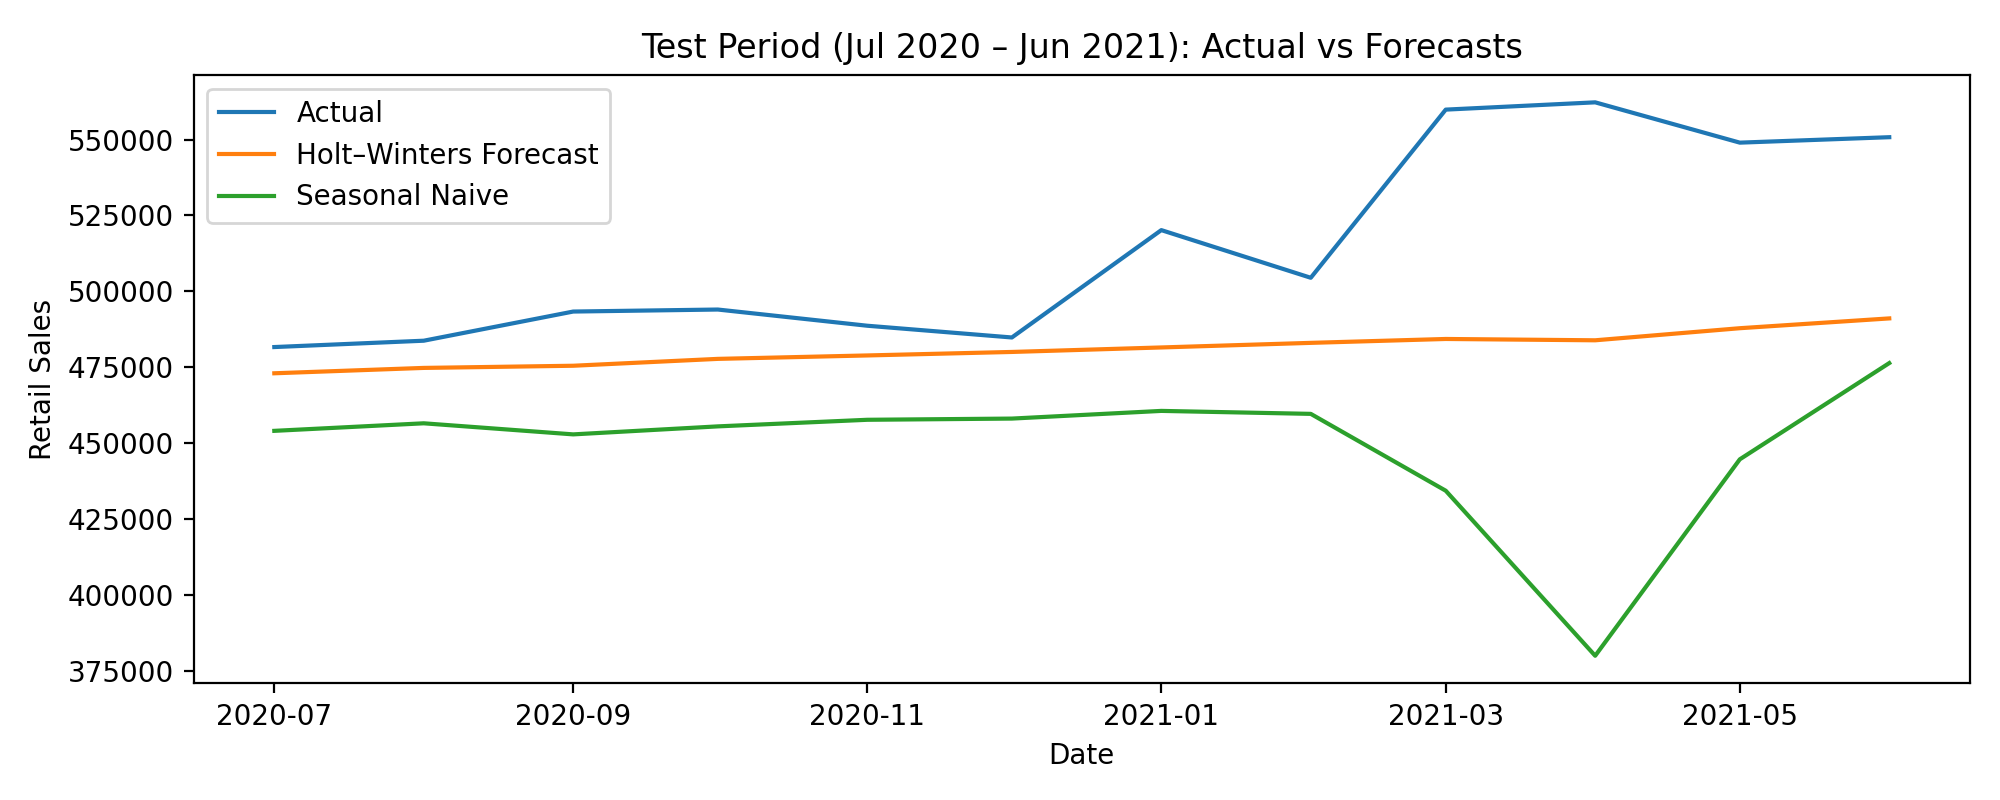

In [17]:
from IPython.display import Image, display
display(Image("retail_sales_full_series.png"))
display(Image("retail_sales_test_forecast.png"))

## Model Evaluation

The model’s performance was measured using the Root Mean Squared Error (RMSE):

| Model | RMSE |
|--------|-----------:|
| Holt–Winters | 42,797.33 |
| Seasonal Naive | 80,273.26 |

The Holt–Winters model achieved a significantly lower RMSE, demonstrating that it captured both the long-term growth trend and the seasonal fluctuations more effectively than the seasonal naive baseline.


## Conclusion

The Holt–Winters model successfully forecasted U.S. monthly retail sales for the final year (July 2020 – June 2021). Its lower RMSE compared to the seasonal naive model shows that including both trend and seasonal patterns improves prediction accuracy. The model clearly captured the long-term upward growth in retail sales, the regular yearly pattern with higher sales during holiday months, and the sudden drop in early 2020 caused by the COVID-19 pandemic, followed by a quick recovery. These results show how time series models can reflect real-world economic changes and consumer behavior.

The Holt–Winters method was chosen instead of ARIMA because it is simpler to apply when the data already shows a clear seasonal pattern. Unlike ARIMA, which requires several parameters and tests to make the data stationary, Holt–Winters directly models level, trend, and seasonality in an easy and understandable way. This makes it a great choice for retail sales data, where we can easily see seasonal peaks and steady growth over time. It also adapts well to sudden changes, such as the disruption caused by the pandemic.

Overall, the project shows that the Holt–Winters model is both practical and accurate for forecasting short-term retail sales. It provides useful insights into how sales behave over time and demonstrates how traditional time series models can help businesses plan and make data-driven decisions.

**Key findings:**

- Retail sales have shown steady long-term growth since 1992.  
- Strong yearly seasonality, with peaks around the holiday shopping months.  
- A major dip in early 2020 corresponds to the economic slowdown during COVID-19.  
- The model produced accurate short-term forecasts and can be useful for business planning and demand forecasting.
